In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!cd "/content/drive/MyDrive/Computer Vision"
import sys
sys.path.insert(0, "/content/drive/MyDrive/Computer Vision")

Mounted at /content/drive


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [3]:
import os
import json
import shutil

import numpy as np
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split

from ultralytics import YOLO

import PIL
import sklearn
import ultralytics

from huggingface_hub import hf_hub_download

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Setting Up Directories

In [4]:
dataset = "KvasirSEG"
root_dir = "/content/drive/MyDrive/Computer Vision/datasets"
dataset_dir = os.path.join(root_dir, dataset, "original")

train_imgs_dir = os.path.join(root_dir, dataset, "images", "train")
valid_imgs_dir = os.path.join(root_dir, dataset, "images", "valid")

train_masks_dir = os.path.join(root_dir, dataset, "masks", "train")
valid_masks_dir = os.path.join(root_dir, dataset, "masks", "valid")

train_labels_dir = os.path.join(root_dir, dataset, "labels", "train")
valid_labels_dir = os.path.join(root_dir, dataset, "labels", "valid")

# Kvasir Dataset and Train-Test Splits

[Kvasir dataset](https://datasets.simula.no/kvasir-seg/) is an open-access collection focused on gastrointestinal polyps. It includes 1000 images, each accompanied by corresponding segmentation masks and bounding box annotations. The image resolutions within the dataset vary, ranging from 332x487 to 1920x1072 pixels. For our purposes, we randomly partitioned the images and their associated segmentation masks into training and testing sets, using an 80% allocation for training and 20% for testing.

In [ ]:
def transfer_images(img_names: list, src_dir: str, dst_dir: str)
    for name in img_names:
        src_path = os.path.join(src_dir, name)
        dst_path = os.path.join(dst_dir, name)
        shutil.copy(src_path, dst_path)

img_src_dir = os.path.join(dataset_dir, "images")
seg_src_dir = os.path.join(dataset_dir, "masks")

img_names = os.listdir(img_src_dir)
seg_names = os.listdir(seg_src_dir)

splits = train_test_split(img_names, seg_names, test_size=0.2, random_state=23)
img_train, img_test, seg_train, seg_test = splits


transfer_images(img_train, img_src_dir, train_imgs_dir)
transfer_images(img_test, img_src_dir, valid_imgs_dir)
transfer_images(seg_train, img_src_dir, train_masks_dir)
transfer_images(seg_test, img_src_dir, valid_masks_dir)

# Normalizing Box Annotations

The KvasirSEG dataset provides bounding box annotations in a JSON file, using the format *(xmin, ymin, xmax, ymax)* to define the top-left and bottom-right corners of each box. To prepare this data for training a YOLO model, the annotations were converted into its required format. At first we calculated normalized center coordinates *(cx, cy)* and rescaled box dimensions with respect to the image size. These normalized annotations were then saved into individual text files, one for each corresponding image.

In [ ]:
with open(os.path.join(dataset_dir, "kavsir_bboxes.json")) as file:
    bboxes = json.load(file)

for name, label in bboxes.items():
    file = open(os.path.join(dataset_dir, "labels", name + ".txt"), "w")
    for box in label["bbox"]:
        cls_idx = 0 if box["label"] == "polyp" else 1

        cx_norm = (box["xmax"] + box["xmin"]) / (2 * label["width"])
        box_width = (box["xmax"] - box["xmin"]) / label["width"]

        cy_norm = (box["ymax"] + box["ymin"]) / (2 * label["height"])
        box_height = (box["ymax"] - box["ymin"]) / label["height"]
        file.write(f"{cls_idx} {cx_norm} {cy_norm} {box_width} {box_height}\n")

    file.close()

# Split Box Annotations to Train and Valid Sets

After normalizing box annotations in individual text files, we split them into train and valid sets.

In [ ]:
original_labels_dir = os.path.join(dataset_dir, "labels")
train_imgs = [names.split(".")[0] for names in os.listdir(train_imgs_dir)]

for name in os.listdir(original_labels_dir):
    label_dir = os.path.join(original_labels_dir, name)
    if name.split(".")[0] in train_imgs:
        shutil.copy(label_dir, train_labels_dir)
    else:
        shutil.copy(label_dir, valid_labels_dir)

# Image-Box Visualization

The images and bounding box annotations in training set are loaded for visualization and testing steps. Image 37 contains 2 major polyps; their bounding boxes in YOLO format are converted into min-max coordinates for easy ploting.

In [48]:
def load_images(imgs_dir: str, labels_dir: str):

    imgs, boxes = [], []

    img_names = os.listdir(imgs_dir)
    img_names.sort()

    label_names = os.listdir(labels_dir)
    label_names.sort()

    for name in img_names:
        pil_image = Image.open(os.path.join(imgs_dir, name))
        imgs.append(pil_image)

    for name in label_names:
        label_file = os.path.join(labels_dir, name)
        box = np.loadtxt(label_file)
        box = np.atleast_2d(box)
        boxes.append(box)

    return imgs, boxes

imgs, boxes_arr = load_images(train_imgs_dir, train_labels_dir)

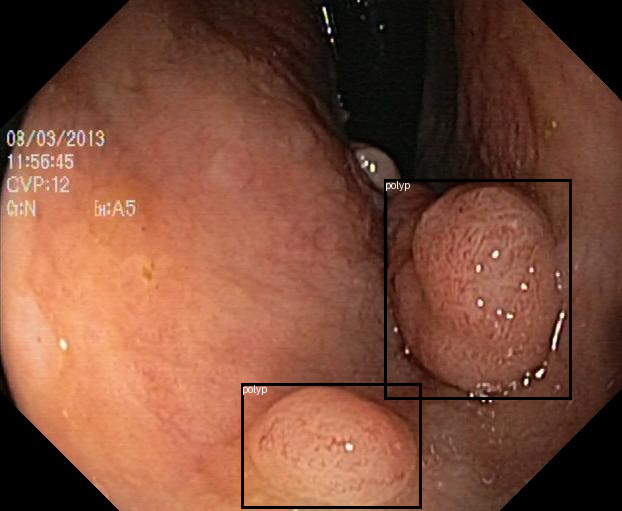

In [49]:
img_id = 37
img, boxes = imgs[img_id], boxes_arr[img_id]
draw = ImageDraw.Draw(img)
width, height = img.size

for box in boxes:
    cls, cx, cy, bwn, bhn = box
    xmin = (cx - bwn / 2) * width
    xmax = (cx + bwn / 2) * width
    ymin = (cy - bhn / 2) * height
    ymax = (cy + bhn / 2) * height

    box_name = "polyp" if cls == 0 else "other"
    draw.rectangle((xmin, ymin, xmax, ymax), outline="black", width=3)
    draw.text((xmin, ymin), box_name, fill="white")

img

# Model Instantiation

In [7]:
model = YOLO("yolov5m.pt")

PRO TIP 💡 Replace 'model=yolov5m.pt' with new 'model=yolov5mu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



100%|██████████| 48.2M/48.2M [00:00<00:00, 193MB/s]


# Model Training

In [8]:
yaml_file = "/content/drive/MyDrive/Computer Vision/datasets/KvasirSEG/kvasir.yaml"
results = model.train(data=yaml_file, epochs=50)

Ultralytics 8.3.120 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: task=detect, mode=train, model=yolov5m.pt, data=/content/drive/MyDrive/Computer Vision/datasets/KvasirSEG/kvasir.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_l

100%|██████████| 755k/755k [00:00<00:00, 13.3MB/s]

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1      5280  ultralytics.nn.modules.conv.Conv             [3, 48, 6, 2, 2]              
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2     65280  ultralytics.nn.modules.block.C3              [96, 96, 2]                   
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    444672  ultralytics.nn.modules.block.C3              [192, 192, 4]                 
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  6   2512896  ultralytics.nn.modules.block.C3              [384, 384, 6]                 
  7                  -1  1   2655744  ultralytics

 13                  -1  2   1182720  ultralytics.nn.modules.block.C3              [768, 384, 2, False]          
 14                  -1  1     74112  ultralytics.nn.modules.conv.Conv             [384, 192, 1, 1]              
 15                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 16             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  2    296448  ultralytics.nn.modules.block.C3              [384, 192, 2, False]          
 18                  -1  1    332160  ultralytics.nn.modules.conv.Conv             [192, 192, 3, 2]              
 19            [-1, 14]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 20                  -1  2   1035264  ultralytics.nn.modules.block.C3              [384, 384, 2, False]          
 21                  -1  1   1327872  ultralytics.nn.modules.conv.Conv             [384,

100%|██████████| 5.35M/5.35M [00:00<00:00, 70.1MB/s]


...

      50/50      8.67G     0.5923     0.4986      1.087         16        640: 100%|██████████| 50/50 [00:06<00:00,  7.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:00<00:00,  7.36it/s]

                   all        200        217      0.907      0.885      0.933      0.778



50 epochs completed in 0.114 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 50.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 50.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.120 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv5m summary (fused): 106 layers, 25,046,374 parameters, 0 gradients, 64.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.46it/s]


                   all        200        217      0.907      0.885      0.933      0.778
                 polyp        200        217      0.907      0.885      0.933      0.778
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/detect/train


# Loading Finetuned Model

The best model recorded as a result of the training was loaded into hugging-face hub. It was retrieved for testing step.

In [6]:
model_path = hf_hub_download(
    repo_id="goktug14/yolov5_kvasir_polyp",
    filename="weights/best.pt"
)

model = YOLO(model_path)

# Testing


0: 544x640 2 polyps, 14.2ms
Speed: 3.7ms preprocess, 14.2ms inference, 2.4ms postprocess per image at shape (1, 3, 544, 640)


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)
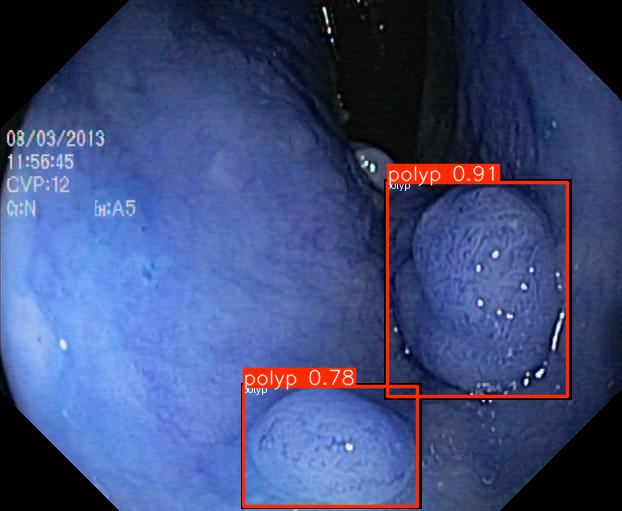

In [50]:
results = model.predict(img)[0]
results.plot()